In [39]:
import pandas as pd
import numpy as np
import mat73
from scipy import io
from operator import itemgetter
from sklearn.linear_model import PoissonRegressor
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import umap

In [40]:
def load_data(filepath, filename):
    data = mat73.loadmat(filepath + "/" + filename)
    X = itemgetter("X")(data)  # covariates
    Y = itemgetter("y")(data)  # spike counts for each cell
    cell_ids = itemgetter("cell_ids")(
        data
    )  # the id of each cell (they are concatenated)
    rec_ids = itemgetter("rec_id")(
        data
    )  # the id of each recording (for multiple experiments)
    return X, Y, cell_ids, rec_ids


def load_multiple_subjects(filepath, filenames):
    X_list = []
    Y_list = []
    cell_ids_list = []
    rec_ids_list = []

    cell_offset = 0
    rec_offset = 0

    for fname in filenames:
        data = mat73.loadmat(filepath + "/" + fname)

        X = data["X"]
        Y = data["y"]
        cell_ids = data["cell_ids"]
        rec_ids = data["rec_id"]

        # Offset IDs so they remain unique across subjects
        cell_ids = cell_ids + cell_offset
        rec_ids = rec_ids + rec_offset

        # Append to lists
        X_list.append(X)
        Y_list.append(Y)
        cell_ids_list.append(cell_ids)
        rec_ids_list.append(rec_ids)

        # Update offsets
        cell_offset = cell_ids.max() + 1
        rec_offset = rec_ids.max() + 1

    # Concatenate across subjects
    X_all = np.concatenate(X_list, axis=1)  # concatenate time dimension
    Y_all = np.concatenate(Y_list, axis=0)
    cell_ids_all = np.concatenate(cell_ids_list, axis=0)
    rec_ids_all = np.concatenate(rec_ids_list, axis=0)

    return X_all, Y_all, cell_ids_all, rec_ids_all


def save_data(filepath, filename, results):
    name = filepath + "/" + filename
    io.savemat(name, results)

In [41]:
# X, Y, cell_ids, rec_ids = load_data("data/simulated", "test1.mat")

# X has shape (5 cvovariates, 15000 x 4 subjects = 60000 time bins)
# Y has shape (60000, 1) - one spike count per time bin
# cell_ids uniquely identify each cell across all subjects
# rec_ids uniquely identify each recording
filenames = ["test1.mat", "test2.mat", "test3.mat", "test4.mat"]
X, Y, cell_ids, rec_ids = load_multiple_subjects("data/simulated", filenames)

In [42]:
X

array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
         0.22682468, -1.08085147],
       [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
         0.44956979,  0.94353064],
       [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
         1.19434176, -0.11757279],
       [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
         0.72757149,  2.63936133],
       [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
        -0.21896155, -1.3196753 ]])

In [43]:
Y

array([0., 5., 0., ..., 0., 0., 0.])

In [44]:
cell_ids

array([ 0.,  0.,  0., ..., 49., 49., 49.])

In [45]:
np.unique(cell_ids, return_counts=True)

(array([ 0.,  1.,  2.,  3.,  4., 10., 11., 12., 13., 14., 25., 26., 27.,
        28., 29., 45., 46., 47., 48., 49.]),
 array([3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000,
        3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000, 3000], dtype=int64))

In [46]:
np.unique(cell_ids).shape

(20,)

In [47]:
rec_ids

array([ 1.,  1.,  1., ..., 13., 13., 13.])

In [48]:
# unique values + counts
np.unique(rec_ids, return_counts=True)

(array([ 1.,  4.,  8., 13.]), array([15000, 15000, 15000, 15000], dtype=int64))

In [49]:
n_features, n_time_x = X.shape
(n_time_y,) = Y.shape

In [50]:
n_features, n_time_x, n_time_y

(5, 60000, 60000)

In [51]:
# For each test subject (4 subjects):
# There are 5 cells, each with 3000 time bins → total 15000 time bins.
# •  Y is all spike counts concatenated across cells:
# • 	first 3000 entries → cell 0
# • 	next 3000 → cell 1
# • 	etc.
# •  X has 5 covariates (features), each sampled over 15000 time bins.

# You already have the key:
# • 	5 cells × 3000 time bins = 15000
# • 	120 repeated trials
# So for each cell:
# • 	3000 time bins
# • 	3000 / 120 = 25 time bins per trial
# So the structure is:
# • 	Per cell: 120 trials × 25 time bins
# • 	Per time bin: 5 covariates in X, 1 spike count in Y
n_cells = 5
bins_per_cell = 3000
trials_per_cell = 120
bins_per_trial = bins_per_cell // trials_per_cell  # 25

# sanity check
assert n_cells * bins_per_cell * 4 == X.shape[1] == Y.shape[0]

In [52]:
# 3. How to isolate data per cell
# To get X and Y for a single cell:
def get_cell_slice(cell_idx, cell_ids):
    idx = np.where(cell_ids == cell_idx)[0]
    return idx


cell_idx = 0  # 0..4

cell_slice = get_cell_slice(cell_idx, cell_ids)
X_cell = X[:, cell_slice]  # shape: (5, 3000)
Y_cell = Y[cell_slice]  # shape: (3000,)

In [53]:
X_cell, Y_cell

(array([[-0.64901377,  1.18116604, -0.7584533 , ...,  0.5445917 ,
          0.22682468, -1.08085147],
        [ 0.90001112, -0.42857532,  0.89944987, ..., -1.72436694,
          0.44956979,  0.94353064],
        [-0.43094213, -0.07587645, -1.54328912, ...,  1.38244384,
          1.19434176, -0.11757279],
        [ 0.21489379,  0.33549953, -0.03029765, ...,  0.85432461,
          0.72757149,  2.63936133],
        [ 2.81058991, -0.1099234 ,  1.33210679, ..., -0.79551777,
         -0.21896155, -1.3196753 ]]),
 array([0., 5., 0., ..., 0., 1., 0.]))

In [54]:
# 4. How to isolate data per trial (within a cell)
# Within a cell:
# • 	3000 time bins
# • 	120 trials
# • 	25 bins per trial
def get_trial_slice(cell_idx, trial_idx, cell_ids, trials_per_cell=120):
    idx = get_cell_slice(cell_idx, cell_ids)
    bins_per_cell = len(idx)
    bins_per_trial = bins_per_cell // trials_per_cell

    start = idx[0] + trial_idx * bins_per_trial
    end = start + bins_per_trial
    return slice(start, end)


cell_idx = 0  # 0..4
trial_idx = 10  # 0..119

trial_slice = get_trial_slice(cell_idx, trial_idx, cell_ids)
X_trial = X[:, trial_slice]  # shape: (5, 25)
Y_trial = Y[trial_slice]  # shape: (25,)

In [55]:
X_trial, Y_trial

(array([[-8.23197262e-01,  3.31905598e-01,  3.43913883e-01,
          3.79747972e-01,  1.08893930e+00,  9.94859162e-01,
          2.08609505e-01, -3.99187785e-01,  5.06010998e-01,
         -1.27763460e-01, -2.54920829e-01, -7.80433484e-02,
         -3.14649337e-01, -3.08418402e-01,  4.01268224e-01,
         -1.29420672e-01,  1.32768323e+00,  6.70786507e-01,
         -6.91714890e-01, -4.92184407e-02, -3.26730968e-01,
          3.03248303e-01,  2.05650030e+00,  1.70719108e+00,
          5.10741754e-01],
        [-1.50430359e-01, -7.51237323e-01,  8.98460587e-02,
          2.67783090e+00, -8.69180423e-04, -9.40429290e-02,
          1.25418774e+00,  1.09454248e+00, -5.73717761e-01,
          1.58221195e+00,  1.51005907e+00, -1.05657509e+00,
          8.40914644e-02,  5.81723830e-01, -3.33396044e-01,
         -8.71868731e-02,  7.77258543e-01, -1.29389632e+00,
         -4.49303801e-01,  2.92758698e-01, -9.17028830e-01,
          1.60882242e+00,  4.97901343e-01,  1.14063957e+00,
          4.6

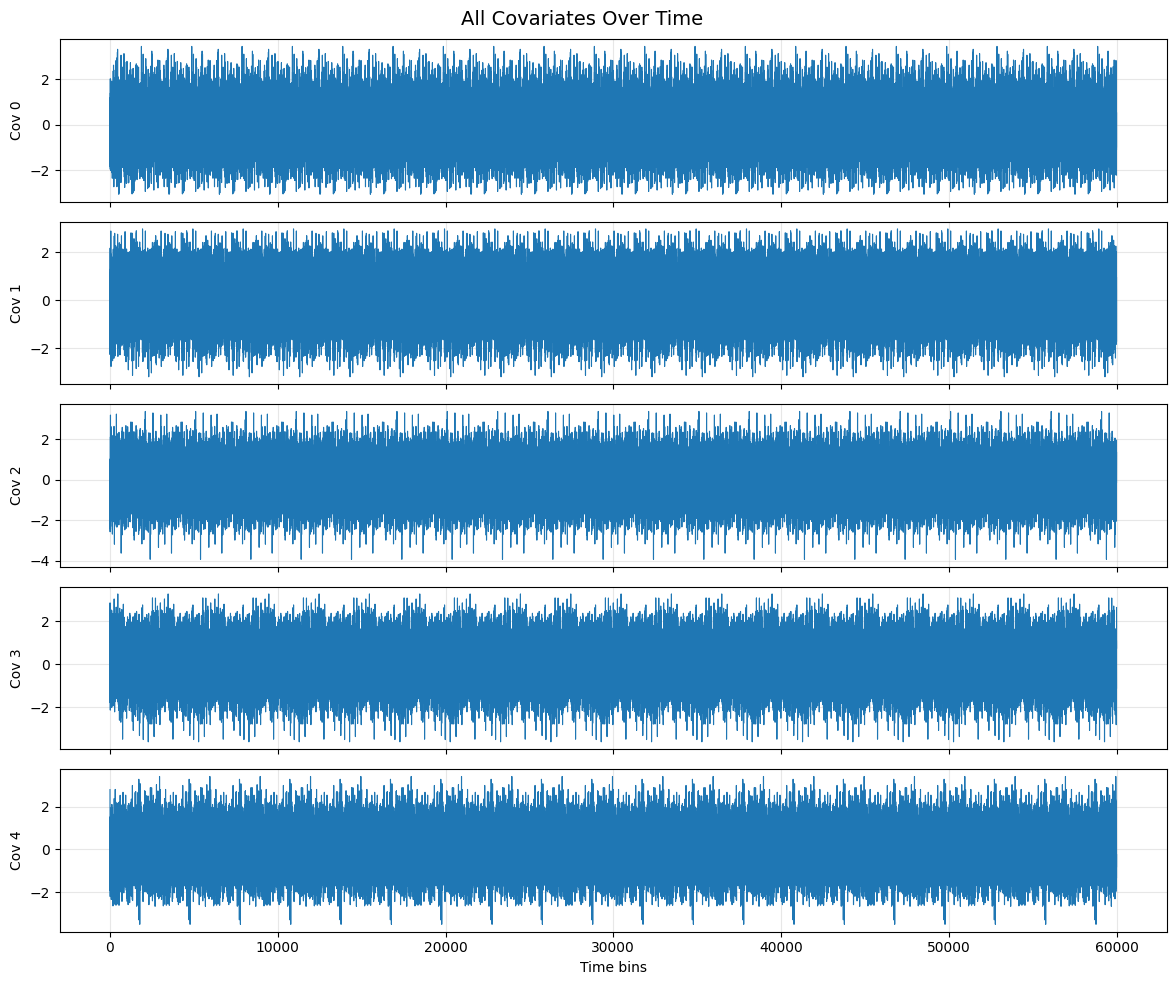

In [56]:
# Plot all covariates across the full recording


def plot_all_covariates(X):
    n_cov = X.shape[0]
    fig, axes = plt.subplots(n_cov, 1, figsize=(12, 2 * n_cov), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X[i], linewidth=0.8)
        axes[i].set_ylabel(f"Cov {i}")
        axes[i].grid(True, alpha=0.3)

    axes[-1].set_xlabel("Time bins")
    plt.suptitle("All Covariates Over Time", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_all_covariates(X)

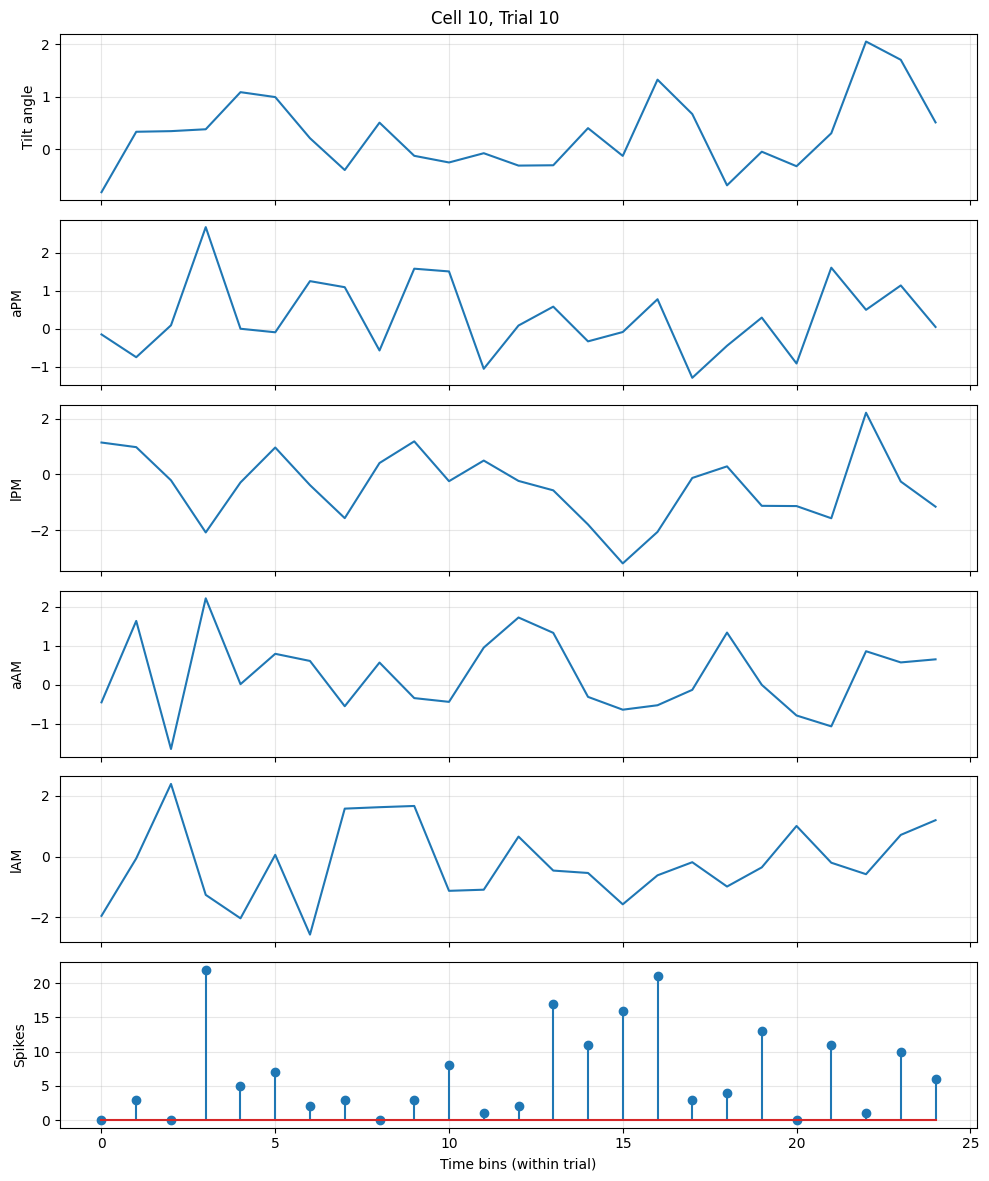

In [57]:
# Plot covariates for a single cell and trial
# Covariate index	Meaning
# 0	Tilt angle
# 1	aPM (angular passive head speed)
# 2	lPM (linear passive head speed)
# 3	aAM (angular active head speed)
# 4	lAM (linear active head speed)
def plot_covariates_and_spikes(X, Y, cell_ids, cell_idx, trial_idx):
    sl = get_trial_slice(cell_idx, trial_idx, cell_ids)
    X_trial = X[:, sl]
    Y_trial = Y[sl]

    cov_names = ["Tilt angle", "aPM", "lPM", "aAM", "lAM"]

    n_cov = X_trial.shape[0]
    fig, axes = plt.subplots(n_cov + 1, 1, figsize=(10, 2 * (n_cov + 1)), sharex=True)

    for i in range(n_cov):
        axes[i].plot(X_trial[i])
        axes[i].set_ylabel(cov_names[i])
        axes[i].grid(True, alpha=0.3)

    axes[-1].stem(Y_trial)
    axes[-1].set_ylabel("Spikes")
    axes[-1].set_xlabel("Time bins (within trial)")
    axes[-1].grid(True, alpha=0.3)

    plt.suptitle(f"Cell {cell_idx}, Trial {trial_idx}")
    plt.tight_layout()
    plt.show()


# Example call
plot_covariates_and_spikes(X, Y, cell_ids, cell_idx=10, trial_idx=10)

In [58]:
# Clustering cells based on different cell features
# Clustering based on functional tuning, not anatomical cell type, tells you:
# • 	whether the simulated cells differ in meaningful ways
# • 	whether your feature extraction pipeline is working
# • 	whether your model can separate cells based on their response structure
# • 	how much diversity exists in the simulated dataset
# The data are simulated:
# • 	clusters reflect differences in simulated tuning, not biological cell types
# • 	still see whether some cells respond more strongly to tilt, passive motion, etc.
# • 	preview of what I'll do with the real dataset later


# feature 1 - correlated with each covariate
def extract_corr_features(X, Y, cell_ids):
    features = []
    for cell in np.unique(cell_ids):
        idx = np.where(cell_ids == cell)[0]
        y_cell = Y[idx]
        x_cell = X[:, idx]
        print(
            f"Cell {cell}, with index={idx}: x_cell shape {x_cell.shape}, y_cell shape {y_cell.shape}"
        )

        # correlation of each covariate with spike train
        corr = [np.corrcoef(x_cell[i], y_cell)[0, 1] for i in range(X.shape[0])]
        features.append(corr)

    return np.array(features)


# feature 2 - poisson GLM weights
def extract_glm_features(X, Y, cell_ids):
    features = []
    for cell in np.unique(cell_ids):
        idx = np.where(cell_ids == cell)[0]
        y_cell = Y[idx]
        x_cell = X[:, idx].T  # sklearn expects (samples, features)

        glm = PoissonRegressor(alpha=0.0, max_iter=1000)
        glm.fit(x_cell, y_cell)

        features.append(glm.coef_)  # 5 weights
    return np.array(features)

In [59]:
def scale_features(features):
    # scale features for fair clustering
    return StandardScaler().fit_transform(features)

In [60]:
# Subject identity dominates clusters (simulated data)
# Z‑score features within each subject
# It removes subject‑level offsets and scales, leaving only relative differences between cells
def zscore_features_within_subject(features, cell_ids, rec_ids):
    unique_subjects = np.unique(rec_ids)
    features_z = features.copy()

    for subj in unique_subjects:
        # find cells belonging to this subject
        subj_cells = np.unique(cell_ids[rec_ids == subj])

        # find feature rows corresponding to these cells
        idx = [np.where(np.unique(cell_ids) == c)[0][0] for c in subj_cells]

        # z-score within subject
        features_z[idx] = (features[idx] - features[idx].mean(axis=0)) / features[
            idx
        ].std(axis=0)

    return features_z

In [61]:
def kmeans_cluster(features, n_clusters=2):
    # Compute kmeans clustering
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    labels = kmeans.fit_predict(features)

    return labels

In [62]:
def hierarchical_cluster(features, method="ward", max_clusters=None):
    # Compute linkage matrix
    Z = linkage(features, method=method)

    # Plot dendrogram
    plt.figure(figsize=(10, 5))
    dendrogram(Z)
    plt.title("Hierarchical Clustering Dendrogram")
    plt.xlabel("Cell index")
    plt.ylabel("Distance")
    plt.grid(alpha=0.3)
    plt.show()

    # If user wants automatic cluster extraction
    if max_clusters is not None:
        labels = fcluster(Z, max_clusters, criterion="maxclust")
        return labels
    return None

In [63]:
# Visualize clusters using PCA (2D)
def plot_clusters(features, labels, title):
    pca = PCA(n_components=2)
    proj = pca.fit_transform(features)

    plt.figure(figsize=(6, 5))
    plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="viridis", s=80)
    plt.title(title)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True, alpha=0.3)
    plt.show()

In [64]:
def plot_umap(features, labels, title):
    reducer = umap.UMAP(
        n_neighbors=5,  # small dataset → small neighborhood
        min_dist=0.1,
        metric="euclidean",
        random_state=42,
    )

    embedding = reducer.fit_transform(features)

    plt.figure(figsize=(6, 5))
    plt.scatter(embedding[:, 0], embedding[:, 1], c=labels, cmap="viridis", s=80)
    plt.title(title)
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.grid(alpha=0.3)
    plt.show()

    return embedding

In [65]:
# Compute the mean feature vector per cluster
def summarize_clusters(features, labels):
    summaries = {}
    for c in np.unique(labels):
        mean_vec = features[labels == c].mean(axis=0)
        summaries[c] = mean_vec
        print(f"\nCluster {c} mean feature vector:")
        print(mean_vec)
    return summaries

In [66]:
# Plot tuning curvers for each cluster
def plot_cluster_tuning(features, labels, title_prefix="Cluster"):
    n_features = features.shape[1]
    clusters = np.unique(labels)

    for c in clusters:
        mean_vec = features[labels == c].mean(axis=0)

        plt.figure(figsize=(6, 4))
        plt.bar(range(n_features), mean_vec)
        plt.xticks(range(n_features), [f"Cov {i}" for i in range(n_features)])
        plt.ylabel("Mean feature value")
        plt.title(f"{title_prefix} {c} tuning profile")
        plt.grid(alpha=0.3)
        plt.show()

In [67]:
# Automatically suggest functional labels
def suggest_labels(cluster_summaries):
    labels = {}
    for c, vec in cluster_summaries.items():
        strongest = np.argmax(np.abs(vec))
        direction = "positive" if vec[strongest] > 0 else "negative"
        labels[c] = f"Strongly tuned to Covariate {strongest} ({direction})"
    return labels

In [68]:
def evaluate_clustering(features, labels):
    score = silhouette_score(features, labels)
    print(f"Silhouette score: {score:.3f}")
    return score

In [69]:
def map_cells_to_clusters(labels, cell_ids):
    unique_cells = np.unique(cell_ids)
    cell_to_cluster = {}

    # labels is already one label per cell, in the same order as unique_cells
    for i, cell in enumerate(unique_cells):
        cell_to_cluster[cell] = labels[i]

    return cell_to_cluster


def print_cluster_membership(labels, cell_ids):
    cell_to_cluster = map_cells_to_clusters(labels, cell_ids)
    clusters = {}
    for cell, cl in cell_to_cluster.items():
        clusters.setdefault(cl, []).append(int(cell))

    for cl, cells in clusters.items():
        print(f"Cluster {cl}: cells {cells}")

    return cell_to_cluster

In [70]:
def cluster_report(features, labels, cell_ids, title_prefix="Cluster"):
    print(f"\n{title_prefix} report:")
    cell_cluster_map = print_cluster_membership(labels, cell_ids)
    summaries = summarize_clusters(features, labels)
    plot_cluster_tuning(features, labels, title_prefix)
    suggested = suggest_labels(summaries)

    print("\nSuggested functional labels:")
    for c, label in suggested.items():
        print(f"Cluster {c}: {label}")

    plot_clusters(features, labels, f"{title_prefix} Clusters")
    plot_umap(features, labels, f"{title_prefix} UMAP")

Cell 0.0, with index=[   0    1    2 ... 2997 2998 2999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 1.0, with index=[3000 3001 3002 ... 5997 5998 5999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 2.0, with index=[6000 6001 6002 ... 8997 8998 8999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 3.0, with index=[ 9000  9001  9002 ... 11997 11998 11999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 4.0, with index=[12000 12001 12002 ... 14997 14998 14999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 10.0, with index=[15000 15001 15002 ... 17997 17998 17999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 11.0, with index=[18000 18001 18002 ... 20997 20998 20999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 12.0, with index=[21000 21001 21002 ... 23997 23998 23999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 13.0, with index=[24000 24001 24002 ... 26997 26998 26999]: x_cell shape (5, 3000), y_cell shape (3000,)
Cell 14.0, with index=[27000 2700

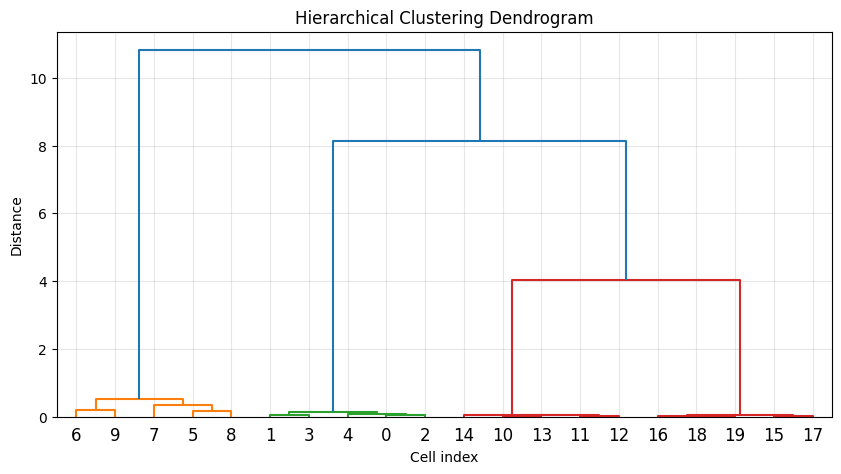

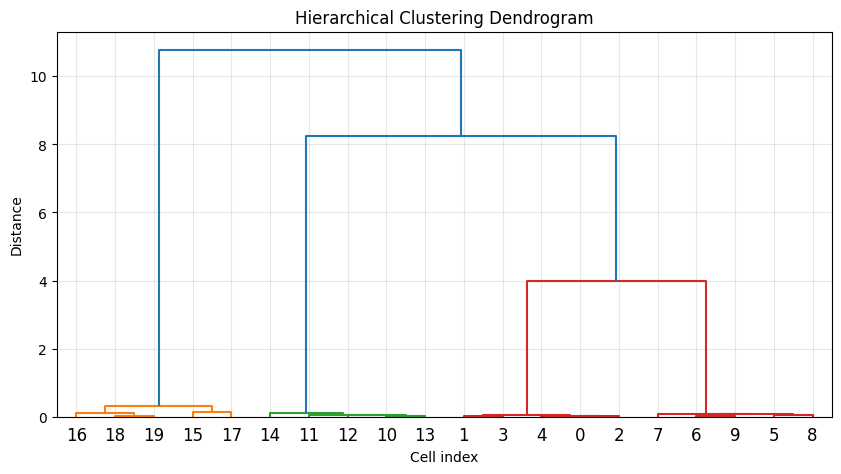

In [71]:
zscore_feats = False
# Option 1: correlation features
corr_features = extract_corr_features(X, Y, cell_ids)
if zscore_feats:
    corr_scaled = zscore_features_within_subject(corr_features, cell_ids, rec_ids)
else:
    corr_scaled = scale_features(corr_features)
corr_labels = kmeans_cluster(corr_scaled, n_clusters=4)
corr_labels_2 = hierarchical_cluster(corr_scaled, max_clusters=5)

# Option 2: GLM weight features
glm_features = extract_glm_features(X, Y, cell_ids)
if zscore_feats:
    glm_scaled = zscore_features_within_subject(glm_features, cell_ids, rec_ids)
else:
    glm_scaled = scale_features(glm_features)
glm_labels = kmeans_cluster(glm_scaled, n_clusters=4)
glm_labels_2 = hierarchical_cluster(glm_scaled, max_clusters=5)

In [72]:
km_score = evaluate_clustering(corr_scaled, corr_labels)  # KMeans
hier_score = evaluate_clustering(corr_scaled, corr_labels_2)  # Hierarchical

Silhouette score: 0.960
Silhouette score: 0.830


Correlation-based clusters: [2 2 2 2 2 1 1 1 1 1 0 0 0 0 0 3 3 3 3 3]

Correlation Feature (KMeans) report:
Cluster 2: cells [0, 1, 2, 3, 4]
Cluster 1: cells [10, 11, 12, 13, 14]
Cluster 0: cells [25, 26, 27, 28, 29]
Cluster 3: cells [45, 46, 47, 48, 49]

Cluster 0 mean feature vector:
[-0.06758305  0.04998384  0.23675576  0.16058374 -0.17459769]

Cluster 1 mean feature vector:
[ 0.21252009  0.41787324 -0.37320575  0.04673305 -0.26389555]

Cluster 2 mean feature vector:
[-0.02116455 -0.05334518  0.27906647 -0.33991912  0.17324067]

Cluster 3 mean feature vector:
[-0.10069777  0.10369923 -0.14983106  0.01928223 -0.0598504 ]


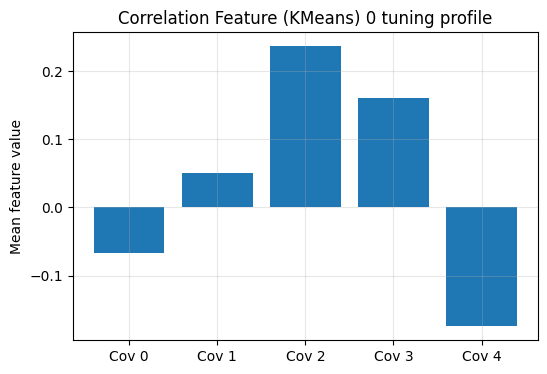

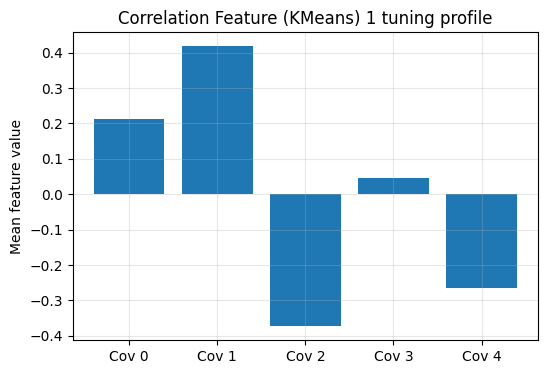

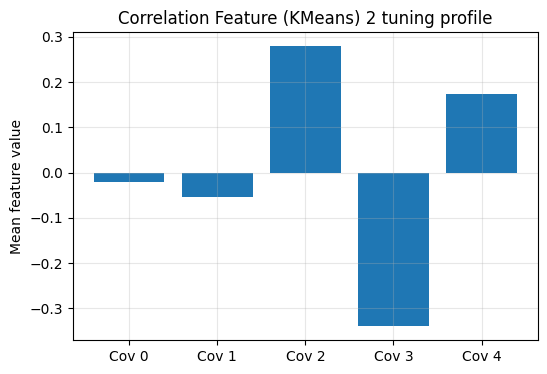

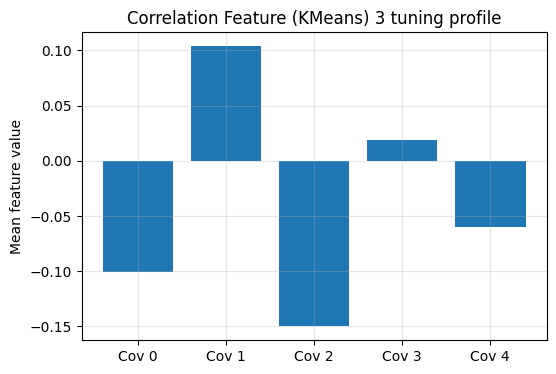


Suggested functional labels:
Cluster 0: Strongly tuned to Covariate 2 (positive)
Cluster 1: Strongly tuned to Covariate 1 (positive)
Cluster 2: Strongly tuned to Covariate 3 (negative)
Cluster 3: Strongly tuned to Covariate 2 (negative)


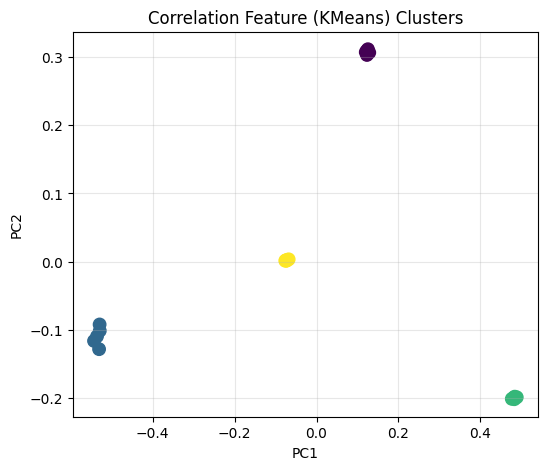

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


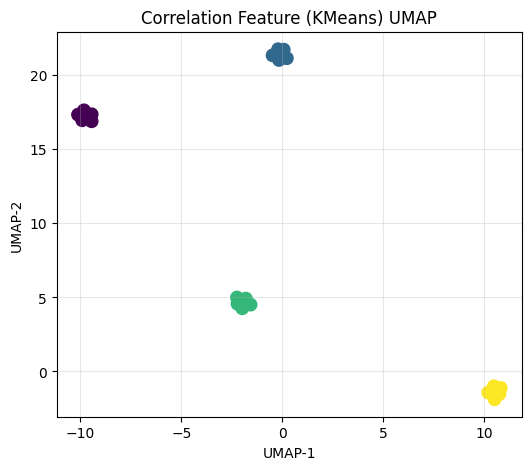


Correlation Feature (Hierarchical) report:
Cluster 3: cells [0, 1, 2, 3, 4]
Cluster 2: cells [10, 12, 13]
Cluster 1: cells [11, 14]
Cluster 4: cells [25, 26, 27, 28, 29]
Cluster 5: cells [45, 46, 47, 48, 49]

Cluster 1 mean feature vector:
[ 0.23282942  0.42893108 -0.35762704  0.042137   -0.27651179]

Cluster 2 mean feature vector:
[ 0.19898054  0.41050135 -0.38359156  0.04979708 -0.25548473]

Cluster 3 mean feature vector:
[-0.02116455 -0.05334518  0.27906647 -0.33991912  0.17324067]

Cluster 4 mean feature vector:
[-0.06758305  0.04998384  0.23675576  0.16058374 -0.17459769]

Cluster 5 mean feature vector:
[-0.10069777  0.10369923 -0.14983106  0.01928223 -0.0598504 ]


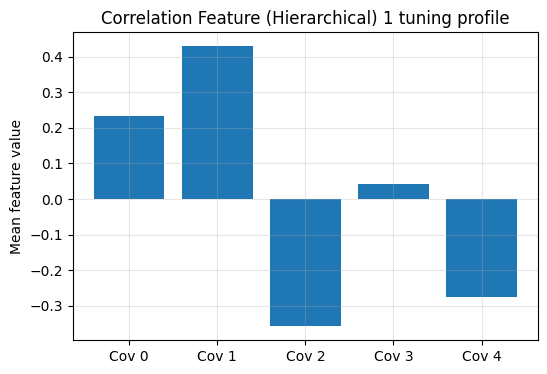

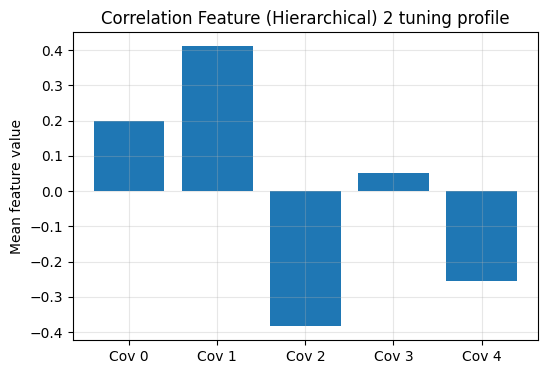

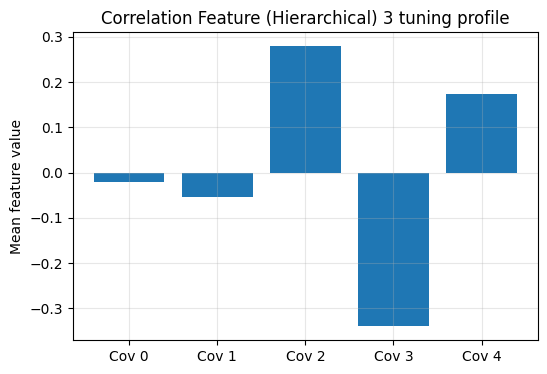

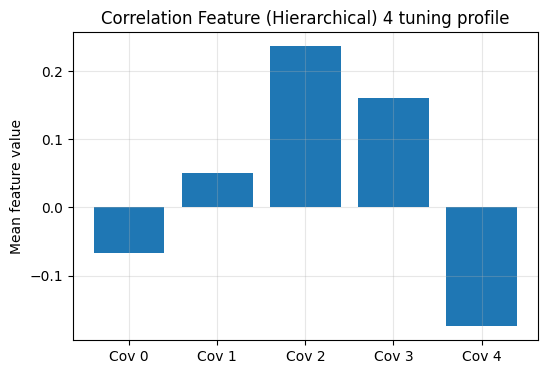

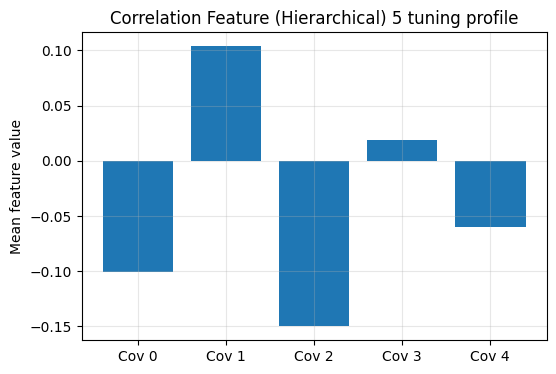


Suggested functional labels:
Cluster 1: Strongly tuned to Covariate 1 (positive)
Cluster 2: Strongly tuned to Covariate 1 (positive)
Cluster 3: Strongly tuned to Covariate 3 (negative)
Cluster 4: Strongly tuned to Covariate 2 (positive)
Cluster 5: Strongly tuned to Covariate 2 (negative)


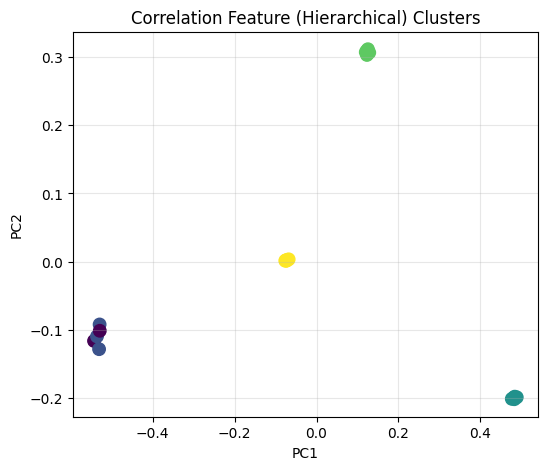

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


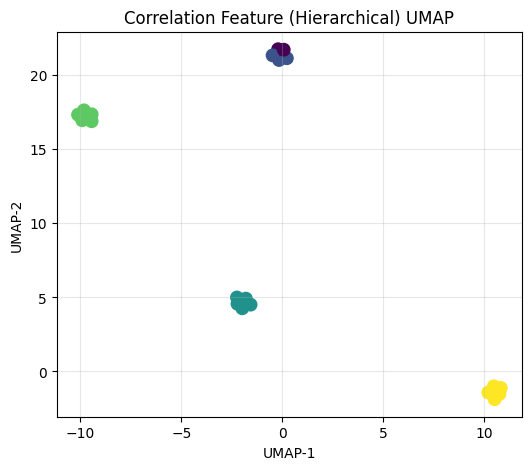

GLM-weight-based clusters: [2 2 2 2 2 3 3 3 3 3 0 0 0 0 0 1 1 1 1 1]

GLM Weight Feature (KMeans) report:
Cluster 2: cells [0, 1, 2, 3, 4]
Cluster 3: cells [10, 11, 12, 13, 14]
Cluster 0: cells [25, 26, 27, 28, 29]
Cluster 1: cells [45, 46, 47, 48, 49]

Cluster 0 mean feature vector:
[-0.33985145 -0.01888317  1.64188716  1.35349806 -1.18959677]

Cluster 1 mean feature vector:
[-1.7069985   2.19558022 -2.56125171  0.24516149 -1.09132549]

Cluster 2 mean feature vector:
[-0.05710566 -0.18565292  0.62660615 -0.75616668  0.39491144]

Cluster 3 mean feature vector:
[ 0.21766761  0.44212034 -0.37636495  0.0376424  -0.27178076]


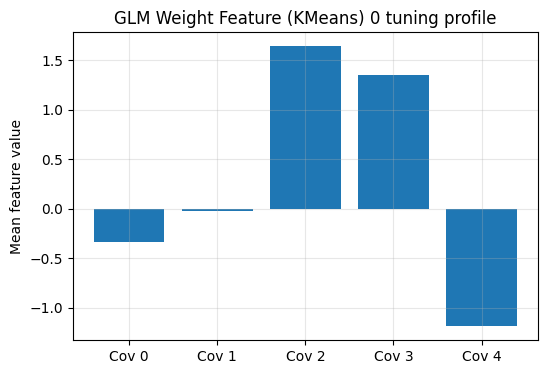

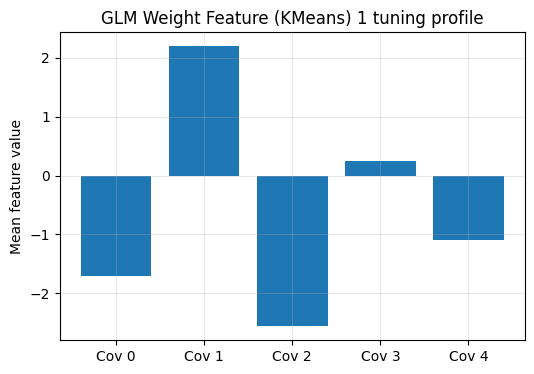

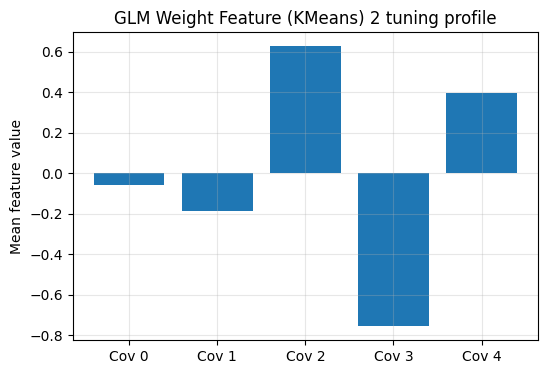

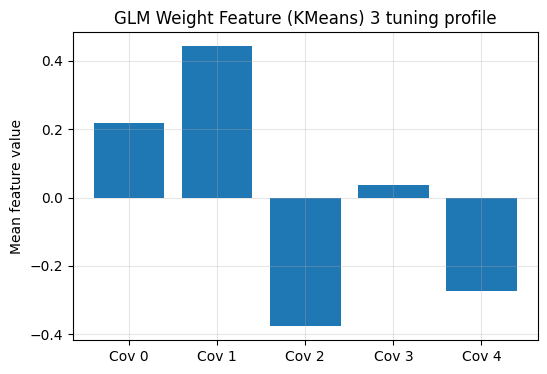


Suggested functional labels:
Cluster 0: Strongly tuned to Covariate 2 (positive)
Cluster 1: Strongly tuned to Covariate 2 (negative)
Cluster 2: Strongly tuned to Covariate 3 (negative)
Cluster 3: Strongly tuned to Covariate 1 (positive)


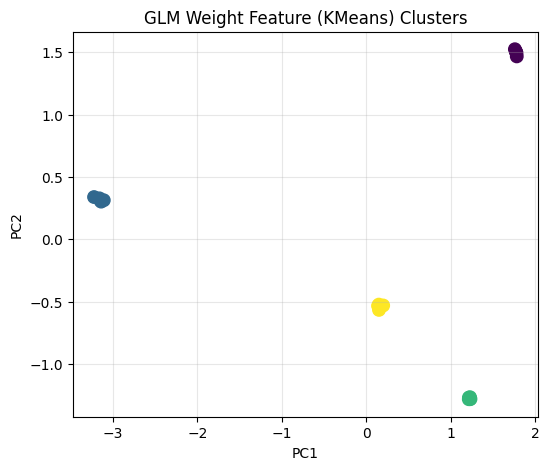

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


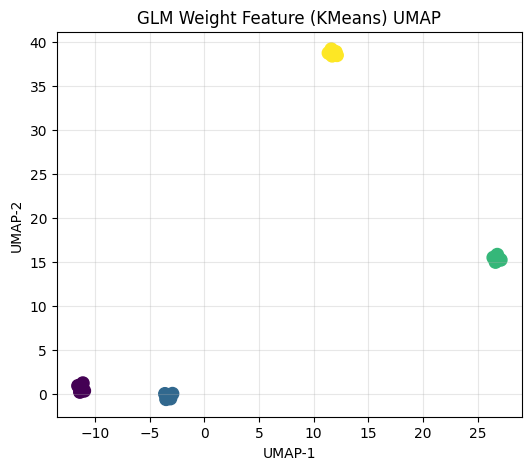


GLM Weight Feature (Hierarchical) report:
Cluster 4: cells [0, 1, 2, 3, 4]
Cluster 5: cells [10, 11, 12, 13, 14]
Cluster 3: cells [25, 26, 27, 28, 29]
Cluster 2: cells [45, 47]
Cluster 1: cells [46, 48, 49]

Cluster 1 mean feature vector:
[-1.69241879  2.16532895 -2.57172872  0.28446874 -1.06105269]

Cluster 2 mean feature vector:
[-1.72886806  2.24095712 -2.54553619  0.18620062 -1.1367347 ]

Cluster 3 mean feature vector:
[-0.33985145 -0.01888317  1.64188716  1.35349806 -1.18959677]

Cluster 4 mean feature vector:
[-0.05710566 -0.18565292  0.62660615 -0.75616668  0.39491144]

Cluster 5 mean feature vector:
[ 0.21766761  0.44212034 -0.37636495  0.0376424  -0.27178076]


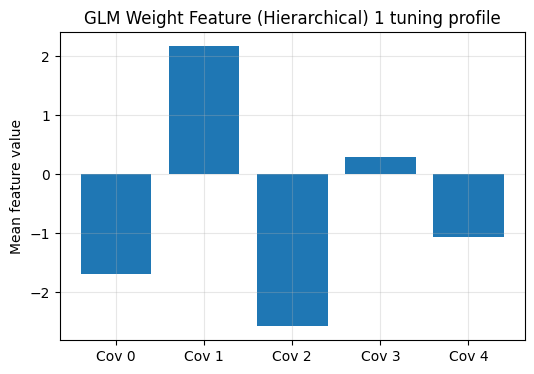

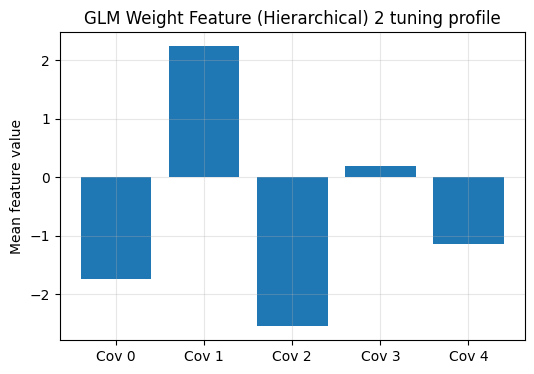

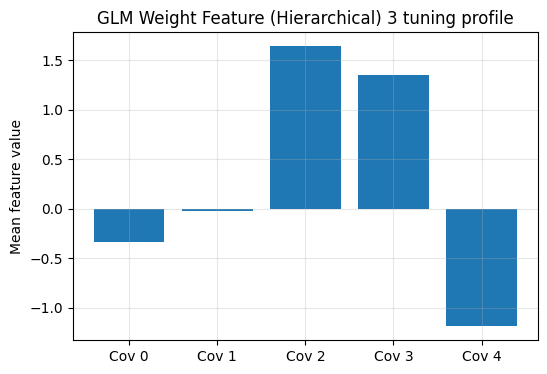

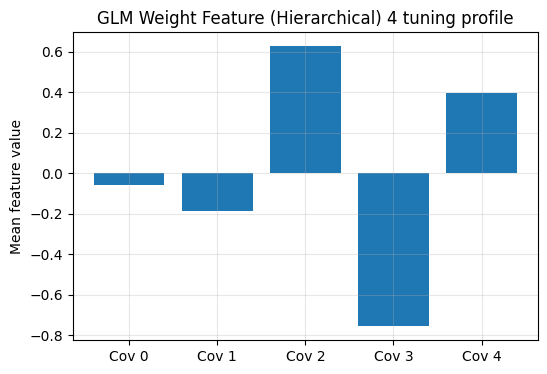

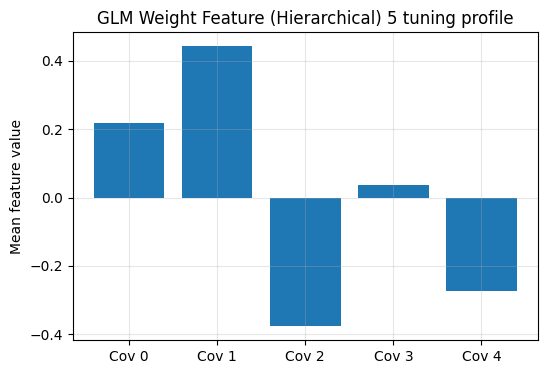


Suggested functional labels:
Cluster 1: Strongly tuned to Covariate 2 (negative)
Cluster 2: Strongly tuned to Covariate 2 (negative)
Cluster 3: Strongly tuned to Covariate 2 (positive)
Cluster 4: Strongly tuned to Covariate 3 (negative)
Cluster 5: Strongly tuned to Covariate 1 (positive)


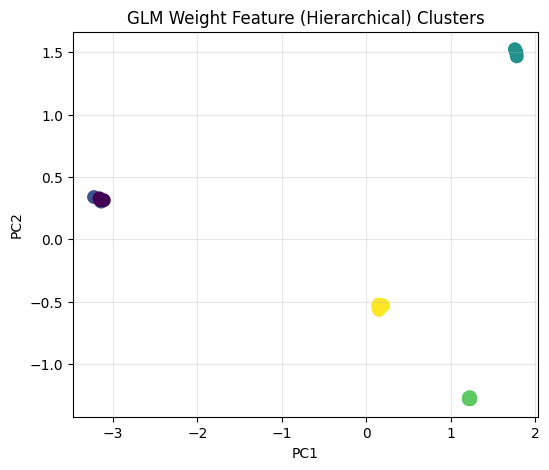

c:\Users\Temitope Shitta\miniconda3\envs\res_proj_1\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


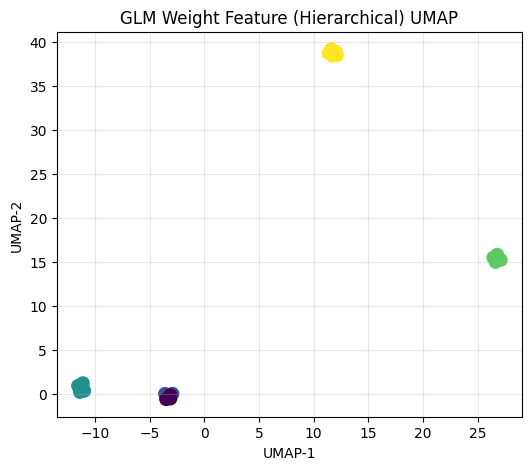

In [73]:
print("Correlation-based clusters:", corr_labels)
cluster_report(corr_features, corr_labels, cell_ids, "Correlation Feature (KMeans)")
cluster_report(
    corr_features, corr_labels_2, cell_ids, "Correlation Feature (Hierarchical)"
)


print("GLM-weight-based clusters:", glm_labels)
cluster_report(glm_features, glm_labels, cell_ids, "GLM Weight Feature (KMeans)")
cluster_report(
    glm_features, glm_labels_2, cell_ids, "GLM Weight Feature (Hierarchical)"
)